Percentiles (10th, 25th, 50th, 75th, 90th): [ 14.5   28.75  52.5   82.5  123.  ]
IQR: 53.75
Outliers: [200]


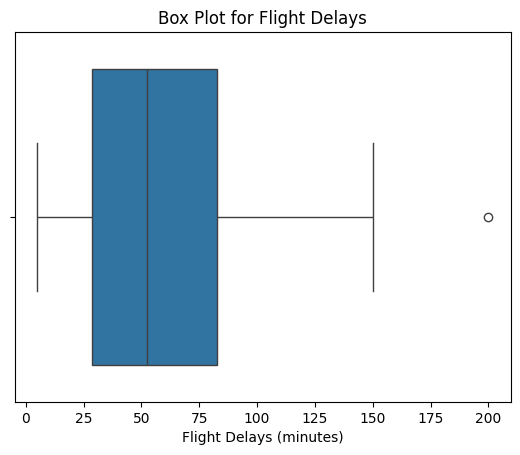

In [6]:
'''Question 1 :
An airline tracks flight delays (in minutes) for 20 flights. Analyze the flight delays to calculate percentiles, detect outliers, and evaluate the overall distribution.
DataSet:
delays = [15, 30, 45, 20, 25, 100, 5, 60, 35, 50, 120, 80, 10, 75, 90, 200, 55, 40, 70, 150]'''

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=delays = [15, 30, 45, 20, 25, 100, 5, 60, 35, 50, 120, 80, 10, 75, 90, 200, 55, 40, 70, 150]
percentile=np.percentile(data,[10, 25, 50, 75, 90])

### IQR
Q1, Q3 = percentile[1], percentile[3]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = [x for x in delays if x < lower_bound or x > upper_bound]
print("Percentiles (10th, 25th, 50th, 75th, 90th):", percentile)
print("IQR:", IQR)
print("Outliers:", outliers if outliers else "No outliers detected.")

# Plot
sns.boxplot(x=delays)
plt.xlabel('Flight Delays (minutes)')
plt.title('Box Plot for Flight Delays')
plt.show()



Mean Salary: 56950.0
Median Salary: 57500.0
Mode Salary: 30000
The data is Left Skewed Negative Skew


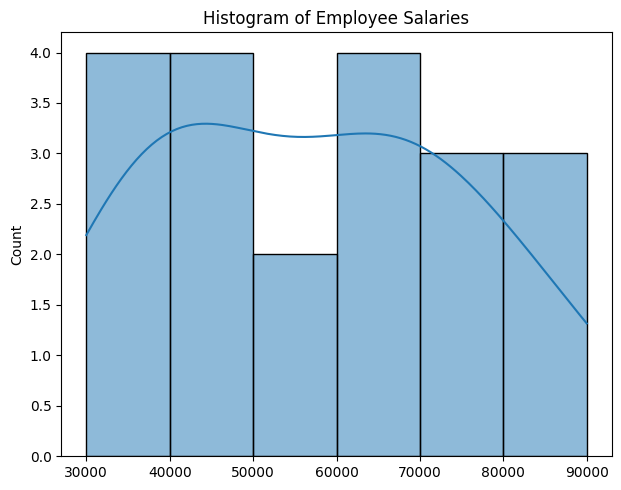

In [13]:
'''Question 2 :
A company wants to analyze the salary distribution of its employees to understand the central tendency and determine whether the data is skewed.
DataSet:
salaries = [30000, 32000, 35000, 37000, 40000, 42000, 45000, 47000, 50000, 55000,
            60000, 62000, 65000, 67000, 70000, 72000, 75000, 80000, 85000, 90000]'''


import pandas as pd
import numpy as np
from scipy import stats


salaries = [30000, 32000, 35000, 37000, 40000, 42000, 45000, 47000, 50000, 55000,
            60000, 62000, 65000, 67000, 70000, 72000, 75000, 80000, 85000, 90000]
Mean=np.mean(salaries)
Median=np.median(salaries)
Mode=stats.mode(salaries)[0]
print("Mean Salary:",Mean)
print("Median Salary:",Median)
print("Mode Salary:",Mode)

# Skewness Check
if Mean > Median:
    print("The data is Right Skewed Positive Skew")
elif Mean < Median:
    print("The data is Left Skewed Negative Skew")
else:
    print("The data is Symmetrical")

## Plot

plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.histplot(salaries, kde=True)
plt.title('Histogram of Employee Salaries')

plt.tight_layout()
plt.show()


In [14]:
''' Question 3:
 A school wants to analyze the exam performance of students across three subjects: Mathematics, Science, and English. How can Data Science concepts be applied to understand their performance?
DataSet:
data = {
    'Student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Mathematics': [85, 78, 92, 88, 70, 95, 60, 80, 90, 76],
    'Science': [80, 85, 88, 70, 75, 92, 55, 82, 89, 78],
    'English': [78, 74, 85, 80, 68, 90, 50, 77, 83, 72]
}'''

data = {
    'Student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Mathematics': [85, 78, 92, 88, 70, 95, 60, 80, 90, 76],
    'Science': [80, 85, 88, 70, 75, 92, 55, 82, 89, 78],
    'English': [78, 74, 85, 80, 68, 90, 50, 77, 83, 72]
}

# Create DataFrame
data = pd.DataFrame(data)
data


,Student,Mathematics,Science,English
0,A,85,80,78
1,B,78,85,74
2,C,92,88,85
3,D,88,70,80
4,E,70,75,68
5,F,95,92,90
6,G,60,55,50
7,H,80,82,77
8,I,90,89,83
9,J,76,78,72


Missing Values:
 Student        0
Mathematics    0
Science        0
English        0
dtype: int64

Descriptive Statistics:
        Mathematics    Science    English
count    10.000000  10.000000  10.000000
mean     81.400000  79.400000  75.700000
std      10.844353  10.895463  11.086027
min      60.000000  55.000000  50.000000
25%      76.500000  75.750000  72.500000
50%      82.500000  81.000000  77.500000
75%      89.500000  87.250000  82.250000
max      95.000000  92.000000  90.000000


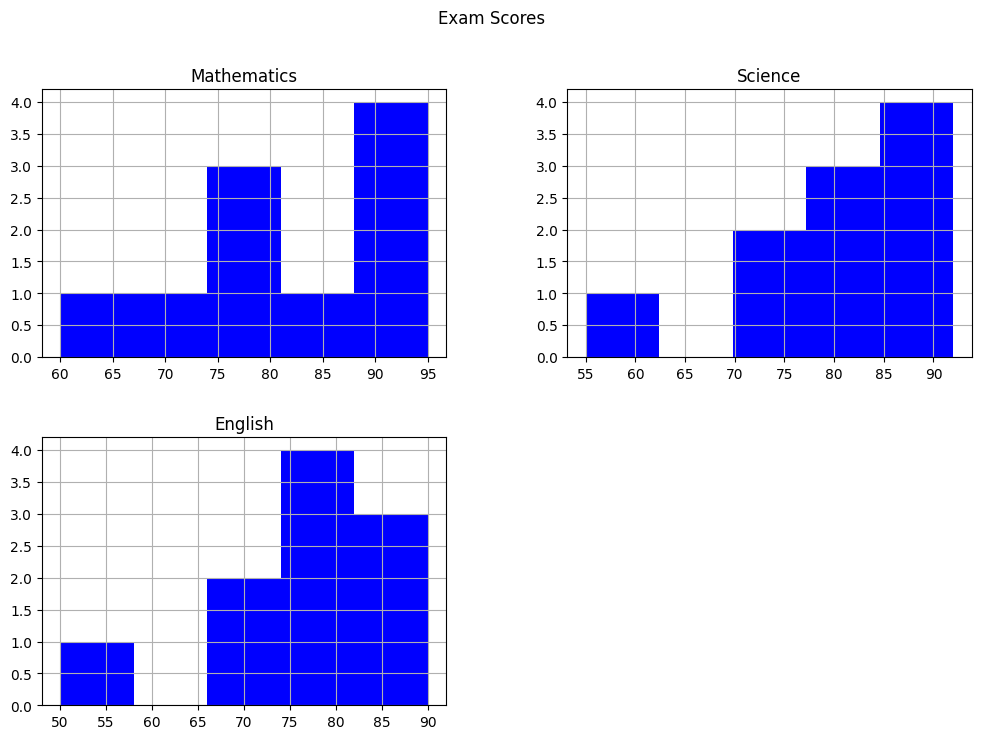


Correlation Matrix:
              Mathematics   Science   English
Mathematics     1.000000  0.792185  0.974318
Science         0.792185  1.000000  0.874999
English         0.974318  0.874999  1.000000


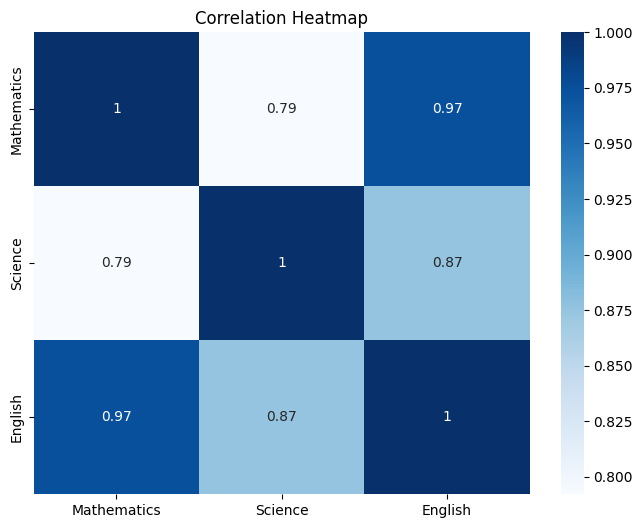

In [15]:
# Data Preprocessing
print("Missing Values:\n", data.isnull().sum())

# Descriptive Statistics
print("\nDescriptive Statistics:\n", data.describe())

# Plot
data[['Mathematics', 'Science', 'English']].hist(bins=5, figsize=(12,8), color='blue')
plt.suptitle('Exam Scores')
plt.show()

# Correlation
correlation_matrix = data[['Mathematics', 'Science', 'English']].corr()
print("\nCorrelation Matrix:\n", correlation_matrix)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()


In [16]:
'''Question 4:
A pharmaceutical company conducted a clinical trial with two groups: one receiving medication and the other a placebo. How do you perform a hypothesis test to determine the effectiveness of the medication?
Dataset:
medication_group = [110, 115, 108, 102, 107, 99, 111, 104, 109, 101]
placebo_group = [120, 125, 130, 122, 128, 119, 124, 127, 123, 126]
'''

from scipy import stats

medication_group = [110, 115, 108, 102, 107, 99, 111, 104, 109, 101]
placebo_group = [120, 125, 130, 122, 128, 119, 124, 127, 123, 126]

t_stat, p_value = stats.ttest_ind(medication_group, placebo_group)
print("T-statistic:", t_stat)
print("P-value:", p_value)

# hypothesis
if p_value <= 0.05:
    print("Reject the null hypothesis: The medication is effective.")
else:
    print("Fail to reject the null hypothesis: No significant effect of the medication.")



T-statistic: -9.201427649220966
P-value: 3.163912817600812e-08
Reject the null hypothesis: The medication is effective.


Mean ratings: 7.5
Median ratings: 7.5
Mode ratings: 7
Standard deviation ratings: 1.746424919657298


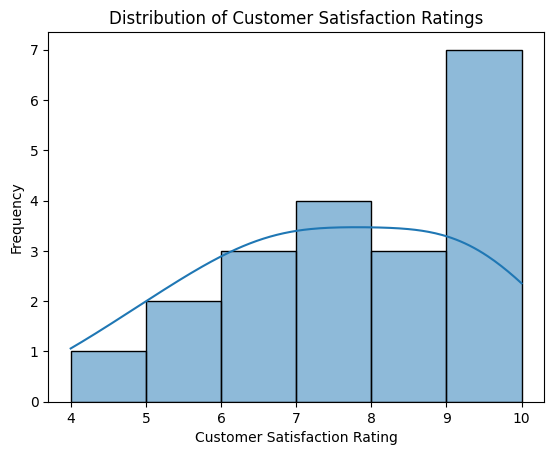

In [19]:
''' Question 5 : A company conducted a customer satisfaction survey where customers rated their experience on a scale of 1 to 10. Analyze the survey results to calculate descriptive statistics and visualize the distribution of customer satisfaction ratings.
Sample DataSet:
ratings = [8, 9, 7, 5, 6, 10, 9, 4, 7, 8,
           6, 9, 10, 5, 8, 7, 6, 9, 10, 7]
'''

import numpy as np
from scipy import stats
ratings = [8, 9, 7, 5, 6, 10, 9, 4, 7, 8,
           6, 9, 10, 5, 8, 7, 6, 9, 10, 7]
Mean=np.mean(ratings)
Median=np.median(ratings)
Mode=stats.mode(ratings)[0]

Std=np.std(ratings)
print("Mean ratings:",Mean)
print("Median ratings:",Median)
print("Mode ratings:",Mode)
print("Standard deviation ratings:",Std)

# Plot
sns.histplot(ratings, kde=True)
plt.xlabel('Customer Satisfaction Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Customer Satisfaction Ratings')
plt.show()

